In [1]:
# # KI Projekt: Vorhersage von Pollenbelastung und Allergierisiko

# Ziel dieses Projekts ist es, auf Basis von Umwelt- und Wetterdaten 
# für das Bundesland Nordrhein-Westfalen (NRW) vorherzusagen, 
# ob ein bestimmter Tag für Allergiker
# ein erhöhtes Risiko darstellt (binary classification: 0 = kein Risiko, 1 = Risiko)

# Im Fokus stehen:
# - Pollenbelastung (Hasel, Erle, Esche, Birke, Gräser)
# - Feinstaub (PM10) als Indikator für Luftverschmutzung
# - Wetterdaten (Temperatur, Niederschlag, Wind, Schnee)

In [2]:
import pandas as pd
import numpy as np
import glob
import os


data_path = "/kaggle/input/alldata"

pollen = pd.read_csv(f"{data_path}/pollen_nrw_2022_2025.csv")
air = pd.read_csv(f"{data_path}/air_quality_pollen_10cities.csv")

pollen["Date"] = pd.to_datetime(pollen["date"]).dt.date
air["Date"] = pd.to_datetime(air["time"]).dt.date

pollen.drop(columns=["date"], inplace=True)
air.drop(columns=["time"], inplace=True)

weather_files = glob.glob(os.path.join(data_path, "*weather.csv"))

weather_data = []
for file in weather_files:
    df = pd.read_csv(file)
    df["Date"] = pd.to_datetime(df["time"]).dt.date
    df.drop(columns=["time"], inplace=True)

city_name = os.path.basename(file).replace("_weather.csv", "")
df["city"] = city_name.capitalize()

weather_data.append(df)

weather_all = pd.concat(weather_data, ignore_index=True)
weather_all.head(), weather_all.shape


pollen = pd.read_csv(f"{data_path}/pollen_nrw_2022_2025.csv")

pollen["Date"] = pd.to_datetime(pollen["date"])
pollen.drop(columns=["date"], inplace=True)

allergens = ["pollen_hazel", "pollen_alder", "pollen_ash", "pollen_birch", "pollen_grass"]

daily_rows = []

for _, row in pollen.iterrows():
    start = row["Date"]
    end = start + pd.Timedelta(days=9)

    for single_date in pd.date_range(start, end):
        new_row = {"Date": single_date}
        for allergen in allergens:
            new_row[allergen] = row[allergen]
        daily_rows.append(new_row)

pollen_daily = pd.DataFrame(daily_rows)
pollen_daily.head(), pollen_daily.shape


air = pd.read_csv(f"{data_path}/air_quality_pollen_10cities.csv")
air["Date"] = pd.to_datetime(air["time"])
air.drop(columns=["time"], inplace=True)
air.rename(columns={"pm10": "PM10"}, inplace=True)

weather_files = glob.glob(os.path.join(data_path, "*weather.csv"))

weather_data = []
for file in weather_files:
    df = pd.read_csv(file) 

    if "time" in df.columns:
        df["Date"] = pd.to_datetime(df["time"]).dt.date
        df.drop(columns=["time"], inplace=True)
    else:
        df["Date"] = pd.to_datetime(df["Date"]).dt.date

    city_name = os.path.basename(file).replace("_weather.csv", "").capitalize()
    df["city"] = city_name
    
    weather_data.append(df)

weather_all = pd.concat(weather_data, ignore_index=True)

weather_all["Date"] = pd.to_datetime(weather_all["Date"])
pollen_daily["Date"] = pd.to_datetime(pollen_daily["Date"])
air["Date"] = pd.to_datetime(air["Date"])

merged = weather_all.merge(air, on=["Date", "city"], how="left") \
                    .merge(pollen_daily, on="Date", how="left")

print("Merged shape:", merged.shape)
merged.head()


Merged shape: (134820, 20)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,Date,city,PM10,latitude,longitude,pollen_hazel,pollen_alder,pollen_ash,pollen_birch,pollen_grass
0,1.4,-0.9,4.5,3.7,0.0,NaN,14.4,47.2,1033.9,360.0,2015-01-01,Wuppertal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.5,0.7,8.1,6.6,0.0,NaN,18.4,52.9,1027.3,150.0,2015-01-02,Wuppertal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.8,0.3,3.3,8.0,0.0,NaN,11.9,36.7,1024.7,0.0,2015-01-03,Wuppertal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.5,-1.0,5.9,0.0,0.0,NaN,8.3,27.4,1032.9,312.0,2015-01-04,Wuppertal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.7,1.1,4.7,0.0,0.0,NaN,11.2,28.4,1032.9,210.0,2015-01-05,Wuppertal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = merged.copy()

pollen_cols = ["pollen_hazel", "pollen_alder", "pollen_ash", "pollen_birch", "pollen_grass"]

for col in pollen_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].clip(lower=0, upper=100) / 100.0

df["pollen_index"] = (
    0.1 * df["pollen_hazel"] +
    0.1 * df["pollen_alder"] +
    0.1 * df["pollen_ash"] +
    0.35 * df["pollen_birch"] +
    0.35 * df["pollen_grass"]
)

df["PM10"] = pd.to_numeric(df["PM10"], errors="coerce")
df["PM10_clipped"] = df["PM10"].clip(lower=0, upper=80)
df["pm_index"] = df["PM10_clipped"] / 80.0

df["risk_score"] = 0.8 * df["pollen_index"] + 0.2 * df["pm_index"]


df["month"] = df["Date"].dt.month

df["hazel_season"] = df["month"].isin([2,3,4]).astype(int)
df["birch_season"] = df["month"].isin([4,5,6]).astype(int)
df["grass_season"] = df["month"].isin([5,6,7,8,9]).astype(int)

df.loc[
    (df["hazel_season"] == 0) &
    (df["birch_season"] == 0) &
    (df["grass_season"] == 0)
] = 0

threshold = 0.15
df["risk_binary"] = (df["risk_score"] >= threshold).astype(int)
df["risk_binary"].value_counts(normalize=True)


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/co

risk_binary
0    0.832169
1    0.167831
Name: proportion, dtype: float64

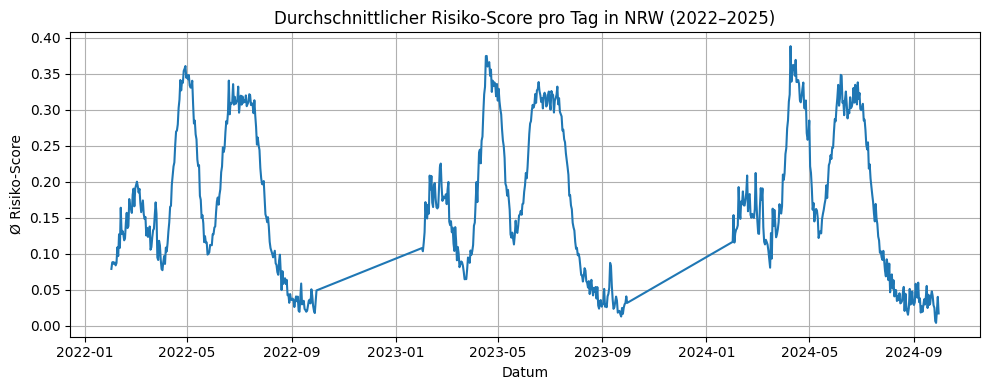

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

df["Date"] = pd.to_datetime(df["Date"])

mask = (df["Date"].dt.year >= 2022) & (df["Date"].dt.year <= 2025)
df_plot = df.loc[mask].copy()

daily_risk = (
    df_plot
    .groupby("Date")["risk_score"].mean()
    .sort_index()
)

plt.figure(figsize=(10,4))
plt.plot(daily_risk.index, daily_risk.values)
plt.title("Durchschnittlicher Risiko-Score pro Tag in NRW (2022–2025)")
plt.xlabel("Datum")
plt.ylabel("Ø Risiko-Score")
plt.grid(True)
plt.tight_layout()
plt.show()

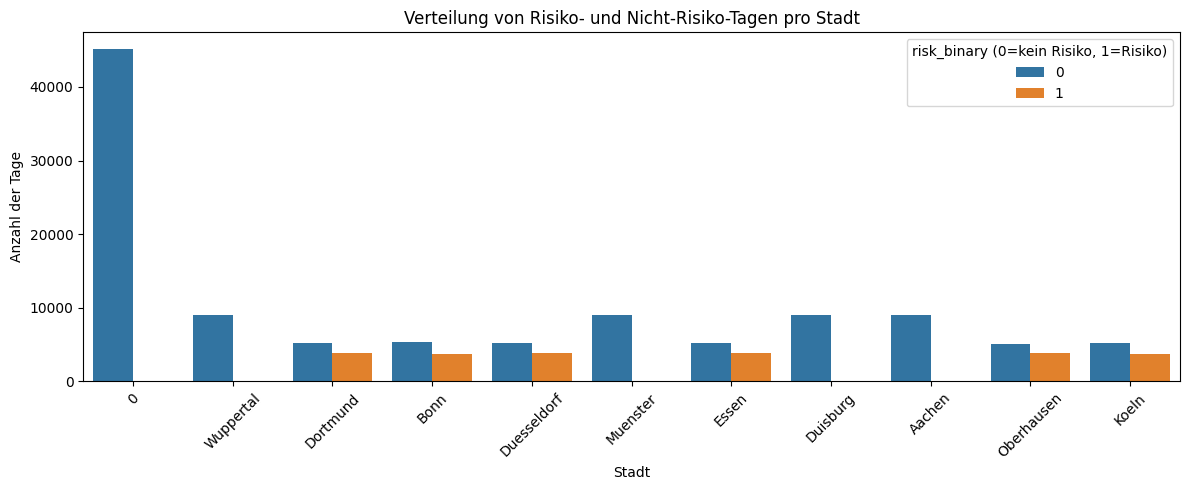

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.countplot(data=df, x="city", hue="risk_binary")
plt.xticks(rotation=45)
plt.xlabel("Stadt")
plt.ylabel("Anzahl der Tage")
plt.title("Verteilung von Risiko- und Nicht-Risiko-Tagen pro Stadt")
plt.legend(title="risk_binary (0=kein Risiko, 1=Risiko)")
plt.tight_layout()
plt.show()

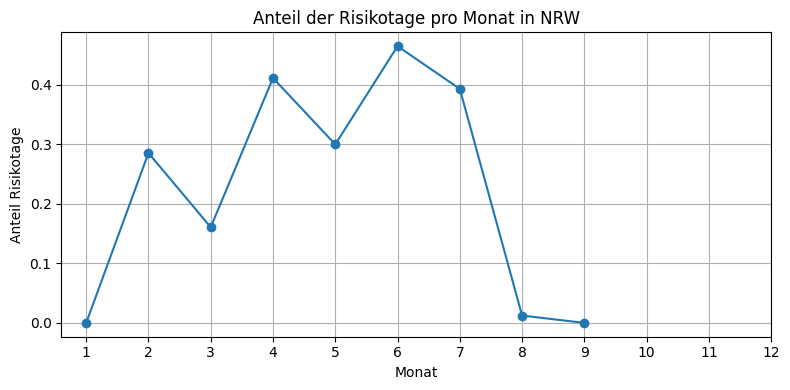

In [6]:
import matplotlib.pyplot as plt

df["month"] = df["Date"].dt.month

monthly_risk = (
    df.groupby("month")["risk_binary"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))
plt.plot(monthly_risk["month"], monthly_risk["risk_binary"], marker="o")
plt.xticks(range(1,13))
plt.xlabel("Monat")
plt.ylabel("Anteil Risikotage")
plt.title("Anteil der Risikotage pro Monat in NRW")
plt.grid(True)
plt.tight_layout()
plt.show()

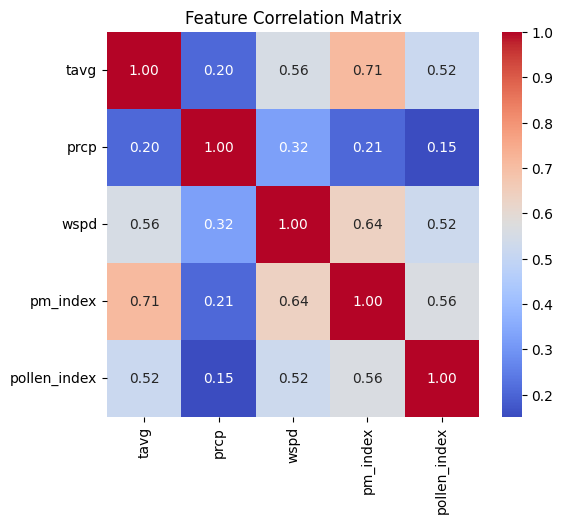

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["tavg", "prcp", "wspd", "pm_index", "pollen_index"]
corr = df[features].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [8]:
import numpy as np
import pandas as pd

features = ["tavg", "tmin", "tmax", "prcp", "snow", "wspd", "pm_index", "pollen_index"]

features = [f for f in features if f in df.columns]
features


data = df.dropna(subset=features + ["risk_binary"]).copy()

print("Shape after dropna:", data.shape)

x = data[features]
y = data["risk_binary"]

x.head(), y.value_counts(normalize=True)


from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)
y_proba = rf.predict_proba(x_test)[:, 1]
print(classification_report(y_test, y_pred, digits=3))


Shape after dropna: (88690, 29)
Train shape: (70952, 8)
Test shape: (17738, 8)

Train class distribution:
risk_binary
0    0.745546
1    0.254454
Name: proportion, dtype: float64

Test class distribution:
risk_binary
0    0.745574
1    0.254426
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0      0.998     0.998     0.998     13225
           1      0.994     0.996     0.995      4513

    accuracy                          0.997     17738
   macro avg      0.996     0.997     0.997     17738
weighted avg      0.997     0.997     0.997     17738



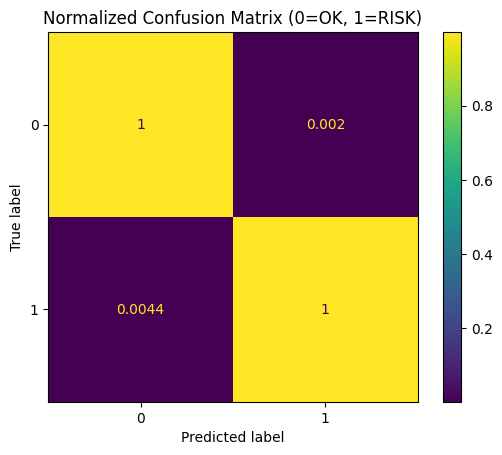

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    rf,
    x_test,
    y_test,
    display_labels=[0, 1],
    normalize="true"
)

plt.title("Normalized Confusion Matrix (0=OK, 1=RISK)")
plt.show()

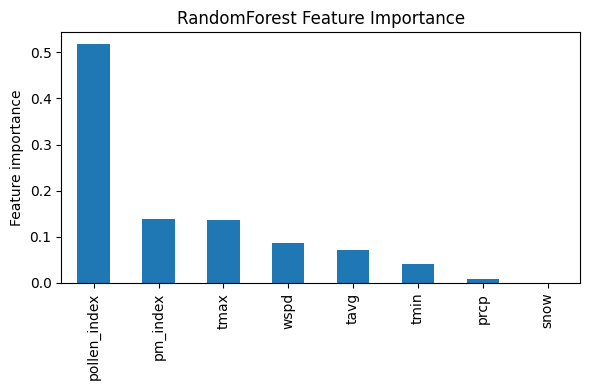

pollen_index    0.517554
pm_index        0.137608
tmax            0.136832
wspd            0.086028
tavg            0.070751
tmin            0.042072
prcp            0.008810
snow            0.000346
dtype: float64

In [10]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind="bar")
plt.ylabel("Feature importance")
plt.title("RandomForest Feature Importance")
plt.tight_layout()
plt.show()

importances

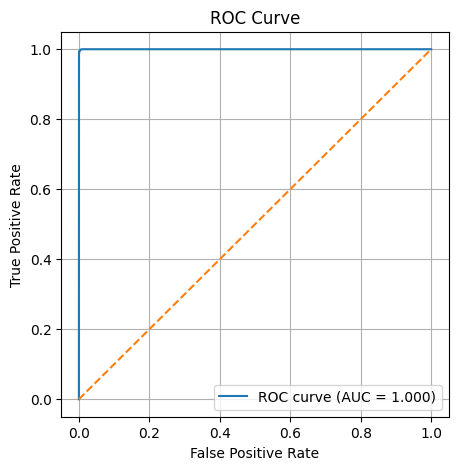

In [11]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled.shape, x_test_scaled.shape

noise_level = 0.05

np.random.seed(42)
noise = np.random.normal(0, noise_level, x_train_scaled.shape)

x_train_noisy = x_train_scaled + noise


x_train_t = torch.tensor(x_train_noisy, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

x_test_t = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

x_train_t.shape, y_train_t.shape, x_test_t.shape, y_test_t.shape

batch_size = 256

train_ds = TensorDataset(x_train_t, y_train_t)
test_ds = TensorDataset(x_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


In [13]:
input_dim = x_train.shape[1]

class AllergyNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0, 25),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0, 25),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model = AllergyNet(input_dim)
model

AllergyNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0, inplace=25)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0, inplace=25)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

num_epochs = 25

train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)


    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()
    
    val_acc = correct / total
    val_accuracies.append(val_acc)

    scheduler.step()

print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - val_acc: {val_acc:.4f}")



Epoch 25/25 - loss: 0.0175 - val_acc: 0.9988


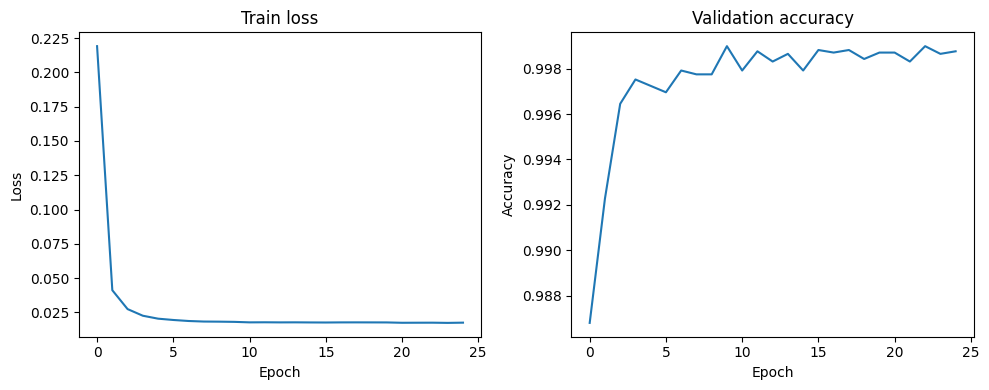

In [15]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")


plt.subplot(1,2,2)
plt.plot(val_accuracies)
plt.title("Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [16]:
model.eval()
with torch.no_grad():
    logits = model(x_test_t)
    probs = torch.sigmoid(logits).squeeze().numpy()

y_pred_nn = (probs >= 0.5).astype(int)

print(classification_report(y_test, y_pred_nn, digits=3))

              precision    recall  f1-score   support

           0      1.000     0.998     0.999     13225
           1      0.995     1.000     0.998      4513

    accuracy                          0.999     17738
   macro avg      0.998     0.999     0.998     17738
weighted avg      0.999     0.999     0.999     17738



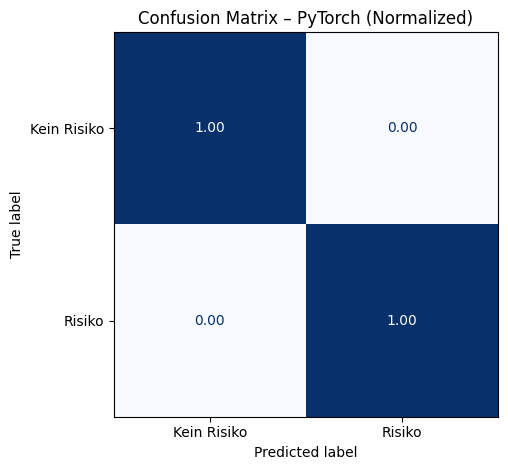

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_nn, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Kein Risiko", "Risiko"])
disp.plot(cmap="Blues", values_format=".2f", colorbar=False)
plt.title("Confusion Matrix – PyTorch (Normalized)")
plt.tight_layout()
plt.show()

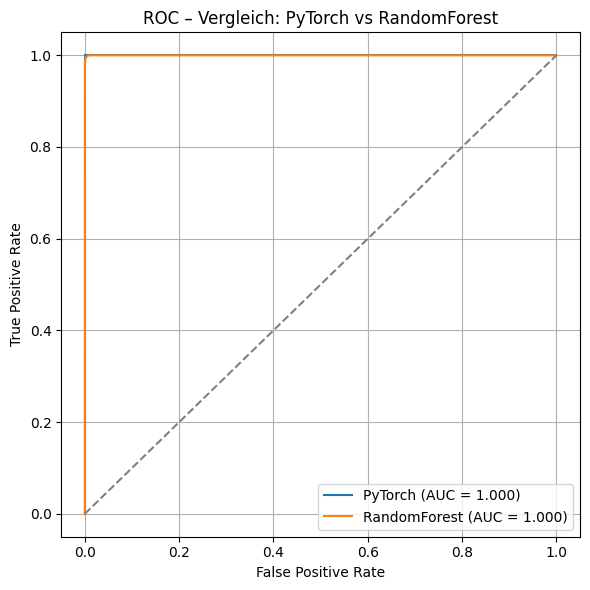

In [18]:
from sklearn.metrics import roc_curve, auc

# PyTorch ROC
fpr_t, tpr_t, _ = roc_curve(y_test, probs)
auc_t = auc(fpr_t, tpr_t)

# RandomForest ROC
y_proba_rf = rf.predict_proba(x_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr_t, tpr_t, label=f"PyTorch (AUC = {auc_t:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC = {auc_rf:.3f})")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC – Vergleich: PyTorch vs RandomForest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
data[features + ["risk_binary", "risk_score", "city", "Date"]].to_csv(
    "allergy_risk_nrw_dataset.csv",
    index=False
)

In [20]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


city = "Essen"      
horizon = 3         


last_date = df["Date"].max()
start_date = last_date + pd.Timedelta(days=1)
future_dates = pd.date_range(start_date, periods=horizon)

target_month = start_date.month

mask = (df["city"] == city) & (df["Date"].dt.month == target_month)
base_means = df.loc[mask, features].mean()

if base_means.isna().any():
    base_means = df.loc[df["city"] == city, features].mean()

future_X = pd.DataFrame(
    [base_means.values] * horizon,
    columns=features
)
future_X["Date"] = future_dates
future_X["city"] = city

future_X

,tavg,tmin,tmax,prcp,snow,wspd,pm_index,pollen_index,Date,city
0,14.043877,9.837988,18.340821,2.838746,0.091457,11.038624,0.190614,0.168214,2024-10-01,Essen
1,14.043877,9.837988,18.340821,2.838746,0.091457,11.038624,0.190614,0.168214,2024-10-02,Essen
2,14.043877,9.837988,18.340821,2.838746,0.091457,11.038624,0.190614,0.168214,2024-10-03,Essen


In [21]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

rf_proba = rf.predict_proba(future_X[features])[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)

model.eval()
with torch.no_grad():

    future_scaled = scaler.transform(future_X[features])
    x_future_t = torch.tensor(future_scaled, dtype=torch.float32)
    output_future = model(x_future_t)
    probs_future = torch.sigmoid(output_future).squeeze().numpy()

nn_pred = (probs_future >= 0.5).astype(int)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "city": city,
    "RF_proba_risk": rf_proba,
    "RF_risk_binary": rf_pred,
    "NN_proba_risk": probs_future,
    "NN_risk_binary": nn_pred
})

forecast_df

,Date,city,RF_proba_risk,RF_risk_binary,NN_proba_risk,NN_risk_binary
0,2024-10-01,Essen,0.993333,1,0.99964,1
1,2024-10-02,Essen,0.993333,1,0.99964,1
2,2024-10-03,Essen,0.993333,1,0.99964,1


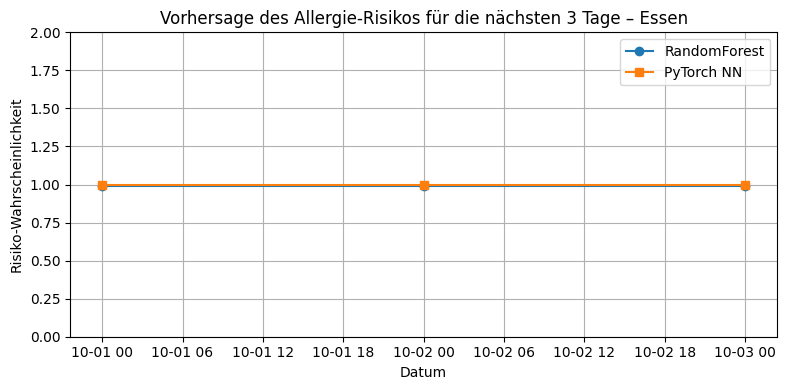

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(forecast_df["Date"], forecast_df["RF_proba_risk"], marker="o", label="RandomForest")
plt.plot(forecast_df["Date"], forecast_df["NN_proba_risk"], marker="s", label="PyTorch NN")
plt.ylim(0, 2)
plt.xlabel("Datum")
plt.ylabel("Risiko-Wahrscheinlichkeit")
plt.title(f"Vorhersage des Allergie-Risikos für die nächsten {horizon} Tage – {city}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()